In [1]:
'''
This notebook is used to evaluate the outputs of SWAT+ model for:

- Long term water balance
- Streamflow, graphically and numerically

'''
from read_swat import *
import matplotlib.pyplot as plt
import dask.dataframe as dd
import rasterio as rast
import numpy as np
import hydroeval

import os

os.chdir('..') # Changing to main SWATPlusForCRIDA

In [3]:
# Paths
#Default/TxtInOut
#Toolbox/Calibration
txt_in_out_dir = "data/CaseStudy/Models/katari-swat-crida-spt/scenarios/Toolbox/Calibration"

basin_wb_yr    = f"{txt_in_out_dir}/basin_wb_yr.txt"    # Annual average Basin Water Balance
channel_sd_mon = f"{txt_in_out_dir}/channel_sd_mon.txt" # Monthly channel flows

obs_chan_path  = "data/CaseStudy/data/swat_inputs/observations/tambilloQmon1981_2021.csv"

In [4]:
# Functions
def Wb_plot_aa(df,vmax,vmin=0):
    delta_wb = df.deltaWb[0]
    percent = abs(delta_wb/df.precip[0])

    print("Annual average basin water balance")
    print(f"Percent = {percent}, Water balance = {delta_wb})")

    # Create a list of the variable names and their corresponding values
    ax, fig = plt.subplots(figsize=(6,4))
    x=["Outflows", "Inflows"]
    y1=np.array([df.et[0],0])
    y2=np.array([df.surq_gen[0],0])
    y3=np.array([df.perc[0],0])
    y4=np.array([df.latq_cha[0],0])
    y5=np.array([0,df.precip[0]])
    x_pos = [1,1.3]
    plt.bar(x_pos, y1, color='mediumseagreen',width=0.2)
    plt.bar(x_pos, y2, bottom=y1, color='grey',width=0.2)
    plt.bar(x_pos, y3, bottom=y1+y2, color='y',width=0.2)
    plt.bar(x_pos, y4, bottom=y1+y2+y3, color='coral',width=0.2)
    plt.bar(x_pos, y5, bottom=y1+y2+y3+y4, color='steelblue',width=0.2)
    plt.title("Basin water balance - Annual Average")
    plt.ylabel("mm H2O")
    plt.legend(["ET","Surface Runoff","Percolation","Lateral flow","Precipitation"],loc="upper right")
    plt.xlim([0.8,2])
    plt.xticks(x_pos, x)
    plt.ylim([vmin,vmax])

## Water Balance Check

Annual average basin water balance
Percent = 0.0010641496132328457, Water balance = 0.5801818181818401)


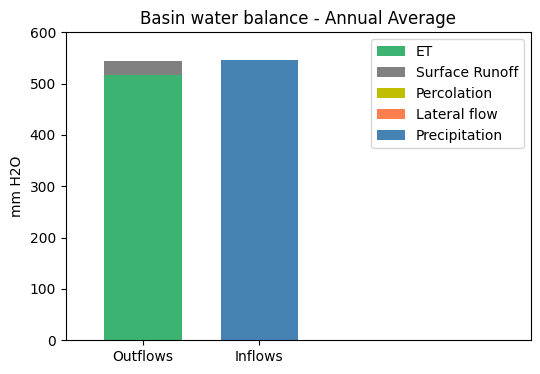

In [5]:
#Basin Water balance check (For the simulated period)
basin_wb_table = swat_table(basin_wb_yr)

df_wb_yr = basin_wb_table.dframe.compute()
df_wb_aa = df_wb_yr [["precip","surq_gen","et","perc","latq_cha"]].mean().to_frame().transpose() # Getting the long term average

df_wb_aa["deltaWb"] = df_wb_aa.precip - df_wb_aa.surq_gen - df_wb_aa.et - df_wb_aa.perc - df_wb_aa.latq_cha # Calculating the difference

Wb_plot_aa(df_wb_aa,600) # Set the Max limit (Now it is 600 mm)

## Streamflow Check

In [6]:
# Reading Observed
obs_flow = pd.read_csv(obs_chan_path)
obs_flow["date"] = pd.to_datetime(obs_flow["date"],dayfirst = True)

Text(0.5, 0, 'Date')

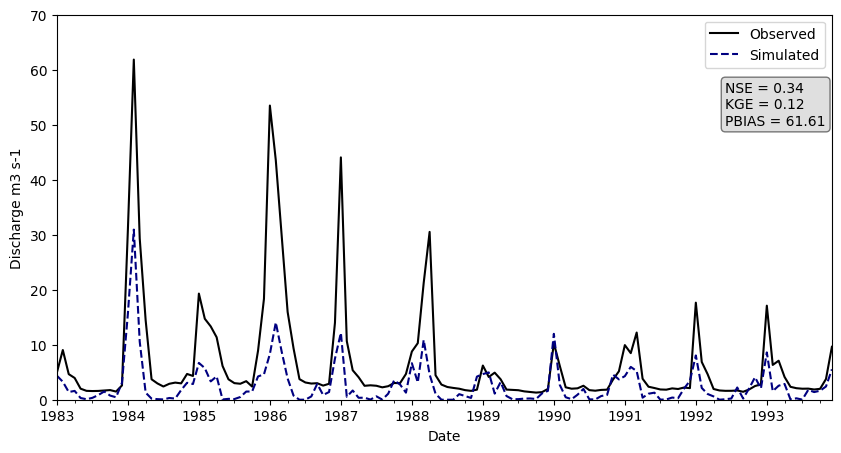

In [7]:
# Set evaluation time limits
start = "1983-01-01"
end   = "1993-12-31"

# Setting variables
obs_flow_var = "q_cms"
sim_flow_var = "flo_out"

# Set plotting limits (m3/s)
vmax = 0
vmin = 70

# Set channel number
chan_nr = 47

# Set plot properties
y_label     = "Discharge m3 s-1"
x_label     = "Date"
box_x_place = "1992-06-01"
box_y_place = 50

# Reading simulation
sim_flow = swat_table(channel_sd_mon).obj_output(chan_nr,sim_flow_var)

# Clipping tables to time limits
obs_flow = obs_flow[obs_flow['date'].between(start,end)]
sim_flow = sim_flow[sim_flow['date'].between(start,end)]

# Calculating numerical indices
observations = obs_flow[obs_flow_var].to_list()
simulations = sim_flow[sim_flow_var].to_list()

nse = hydroeval.evaluator(hydroeval.nse,simulations,observations)[0]
kge, r, alpha, beta = hydroeval.evaluator(hydroeval.kge, simulations, observations)
kge=kge[0]
pbias = hydroeval.evaluator(hydroeval.pbias,simulations,observations)[0]
# For more stats: https://pypi.org/project/hydroeval/


# Plotting
fig , ax = plt.subplots(figsize=(10,5))

obs_flow.plot("date",obs_flow_var,ax=ax,label = "Observed",color="k")
sim_flow.plot("date",sim_flow_var,ax=ax,label = "Simulated",color="navy",linestyle="--")
ax.set_ylim([vmax,vmin])

props = dict(boxstyle='round', facecolor='silver', alpha=0.5)
ax.text(box_x_place,box_y_place,f"NSE = {nse:.2f}"+"\n"+f"KGE = {kge:.2f}"+"\n"+f"PBIAS = {pbias:.2f}",bbox=props)
ax.set_ylabel(y_label)
ax.set_xlabel(x_label)